# EDA Analysis
Checking if the parsed energy commodity data needs normalization (UOM, Currency, Outliers, etc.).

*Note: This notebook executes all aggregations server-side on Snowflake to handle the 163M row scale efficiently.*

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from utility.snowflake_client import SnowflakeClient

sns.set_theme(style="whitegrid")
sf = SnowflakeClient()
sf.connect()

## 1. Basic Information & Missing Values
Let's see the total scale of the dataset and how many values are missing.

In [20]:
query_info = """
SELECT 
    COUNT(*) as TOTAL_ROWS,
    COUNT(VALUE) as NON_NULL_VALUES,
    COUNT(PRODUCT) as NON_NULL_PRODUCTS,
    COUNT(DISTINCT PRODUCT) as UNIQUE_PRODUCTS,
    COUNT(DISTINCT UOM) as UNIQUE_UOMS,
    COUNT(DISTINCT CURRENCY) as UNIQUE_CURRENCIES
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
"""
df_info = sf.read_sql(query_info)
df_info

,TOTAL_ROWS,NON_NULL_VALUES,NON_NULL_PRODUCTS,UNIQUE_PRODUCTS,UNIQUE_UOMS,UNIQUE_CURRENCIES
0,162685188,162685188,162685188,6345,29,42


## 2. Top Products
What are the most frequent products in the dataset?

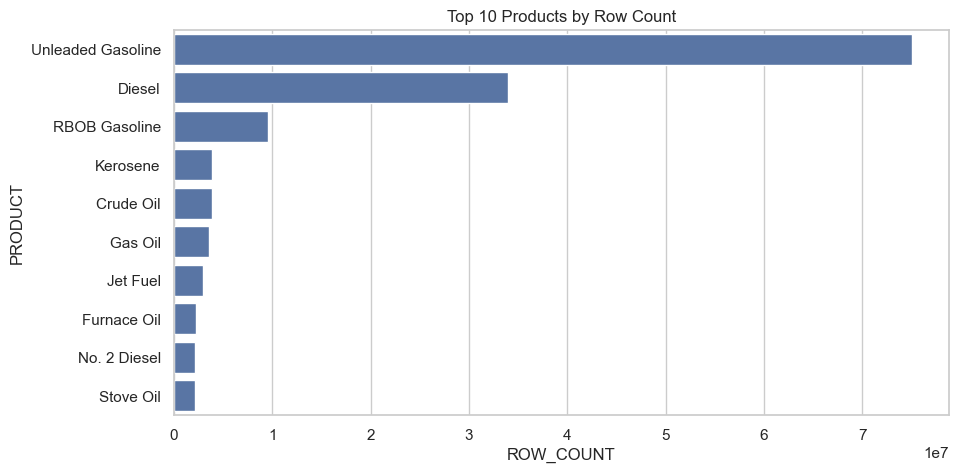

In [21]:
query_top_products = """
SELECT PRODUCT, COUNT(*) as ROW_COUNT
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
GROUP BY PRODUCT
ORDER BY ROW_COUNT DESC
LIMIT 10
"""
df_top = sf.read_sql(query_top_products)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top, y='PRODUCT', x='ROW_COUNT', color='b')
plt.title('Top 10 Products by Row Count')
plt.show()

## 3. UOM & Currency Variations
Do we have the same `PRODUCT` traded in multiple `UOM` (Units of Measure) or `CURRENCY`? If so, this requires normalization before modeling.

In [22]:
query_variations = """
SELECT 
    PRODUCT, 
    COUNT(DISTINCT UOM) as NUM_UOMS, 
    COUNT(DISTINCT CURRENCY) as NUM_CURRENCIES,
    COUNT(*) as TOTAL_ROWS
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
GROUP BY PRODUCT
HAVING NUM_UOMS > 1 OR NUM_CURRENCIES > 1
ORDER BY TOTAL_ROWS DESC
LIMIT 10
"""
df_vars = sf.read_sql(query_variations)
print("Products with multiple UOMs or Currencies:")
df_vars

Products with multiple UOMs or Currencies:


,PRODUCT,NUM_UOMS,NUM_CURRENCIES,TOTAL_ROWS
0,Unleaded Gasoline,2,2,75079777
1,Diesel,3,4,33972171
2,RBOB Gasoline,3,3,9513739
3,Kerosene,5,5,3886410
4,Crude Oil,6,4,3878059
5,Gas Oil,4,2,3564289
6,Jet Fuel,2,3,2938822
7,Furnace Oil,2,2,2193822
8,No. 2 Diesel,2,2,2164431
9,Stove Oil,2,2,2131898


In [23]:
query_uom_splits = """
SELECT 
    PRODUCT, 
    UOM, 
    CURRENCY, 
    COUNT(*) as ROW_COUNT
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
WHERE PRODUCT IN (
    SELECT PRODUCT FROM (
        SELECT PRODUCT, COUNT(*) as cnt 
        FROM CMDTYA.PUBLIC.PRICEDATA_PARSED 
        GROUP BY PRODUCT ORDER BY cnt DESC LIMIT 3
    )
)
GROUP BY PRODUCT, UOM, CURRENCY
ORDER BY PRODUCT, ROW_COUNT DESC
"""
df_splits = sf.read_sql(query_uom_splits)
print("UOM/Currency splits for top 3 products:")
df_splits

UOM/Currency splits for top 3 products:


,PRODUCT,UOM,CURRENCY,ROW_COUNT
0,Diesel,GAL,USC,24170130
1,Diesel,GAL,USD,7364381
2,Diesel,LTR,CAC,2426115
3,Diesel,N/A,N/A,11545
4,RBOB Gasoline,GAL,USD,8152651
5,RBOB Gasoline,BBL,USD,1206408
6,RBOB Gasoline,GAL,USC,133235
7,RBOB Gasoline,N/A,N/A,21445
8,Unleaded Gasoline,GAL,USC,68234530
9,Unleaded Gasoline,LTR,CAC,6845247


## 4. Value Distributions & Outliers
Let's look at the basic statistics (min, max, mean) for the top products. If the range is extremely wide or negative values exist, we may need clipping or Z-score normalization.

In [24]:
query_stats = """
SELECT 
    PRODUCT, 
    UOM, 
    CURRENCY, 
    COUNT(*) as ROW_COUNT,
    MIN(VALUE) as MIN_VAL,
    MAX(VALUE) as MAX_VAL,
    AVG(VALUE) as MEAN_VAL,
    STDDEV(VALUE) as STD_VAL
FROM CMDTYA.PUBLIC.PRICEDATA_PARSED
WHERE VALUE IS NOT NULL
GROUP BY PRODUCT, UOM, CURRENCY
ORDER BY ROW_COUNT DESC
LIMIT 15
"""
df_stats = sf.read_sql(query_stats)
df_stats

,PRODUCT,UOM,CURRENCY,ROW_COUNT,MIN_VAL,MAX_VAL,MEAN_VAL,STD_VAL
0,Unleaded Gasoline,GAL,USC,68234530,8.00,697.71,236.711334498091,65.530750
1,Diesel,GAL,USC,24170130,-100.00,16970.00,241.201948157987,76.598767
2,RBOB Gasoline,GAL,USD,8152651,0.00,611789.00,2072.705439538844,17345.389761
3,Diesel,GAL,USD,7364381,0.00,689683.00,2393.543489136996,18012.002199
4,Unleaded Gasoline,LTR,CAC,6845247,17.18,551.14,89.538471600806,41.657445
5,Kerosene,GAL,USC,3788718,76.63,699.90,289.410166132713,80.451138
6,Crude Oil,BBL,USD,3710026,0.00,39991.00,273.114123170565,1369.346397
7,Gas Oil,MT,USD,3489117,-6294.00,1633100.00,4733.252536455527,33195.018940
8,Jet Fuel,GAL,USC,2935474,-49.00,691.62,240.625984064584,76.800177
9,Diesel,LTR,CAC,2426115,26.04,634.72,97.404310451071,54.544102


In [25]:
sf.close()